## Prediction using single feature

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


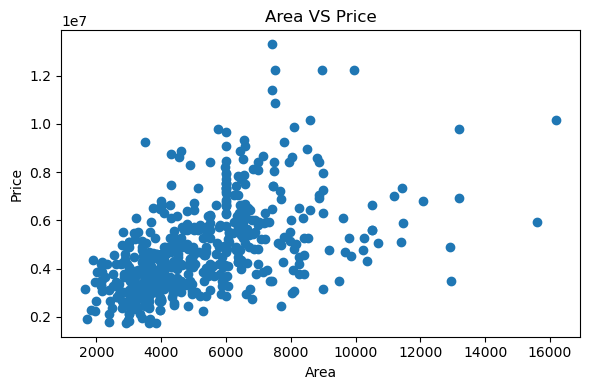

In [4]:
plt.figure(figsize=(6,4))
plt.scatter(df["area"], df["price"])
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area VS Price")
plt.tight_layout()

In [5]:
X = df[["area"]]
y = df["price"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

In [9]:
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.27287851871974633
MAE: 1474748.1337969352
RMSE: 1917103.7021424235


#### r2 score is 0.27 i.e. the model can only 27% variance in the target 

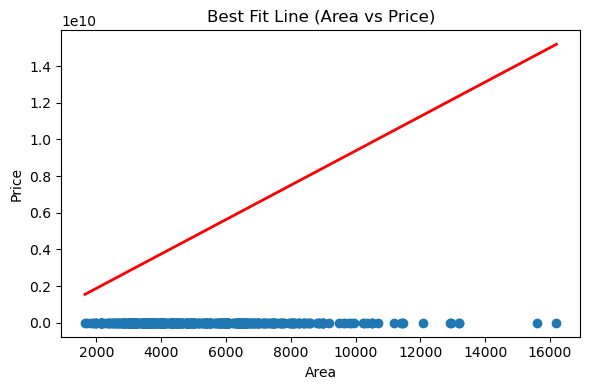

In [10]:
X_sorted = np.sort(X.values, axis=0)
y_sorted_pred = lr_model.predict(X_sorted)

plt.figure(figsize=(6,4))
plt.scatter(X, y)
plt.plot(X_sorted, y_sorted_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Best Fit Line (Area vs Price)")
plt.tight_layout()

Using only one feature (area) is insufficient because it fails to capture most of the factors affecting the target, and the low R² score reflects this by showing that the model explains only a small portion of the data’s variance.

## Prediction using all features

##### encoding categorical features
- label ecnoding / mapping for binary categories (mainroad, guestroom)
-  One Hot Encoding for multiple features (furnished)
-   one hot encoding is used instead of mapping because model will learn wrong patterns...for eg.
-  furnished = 0, semi-furnished=1, unfurnished=2
- model will interpret this as furnished > semi-furnished > unfurnished (priority is set)

In [11]:
binary_cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes':1,'no':0})

In [12]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded = encoder.fit_transform(df[['furnishingstatus']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out())
df = pd.concat([df.drop('furnishingstatus', axis=1), encoded_df], axis=1)

In [13]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0.0,0.0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0.0,0.0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1.0,0.0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0.0,0.0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0.0,0.0


In [14]:
from sklearn.decomposition import PCA
X_new = df.drop('price', axis=1)
X_scaled = scaler.fit_transform(X_new)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

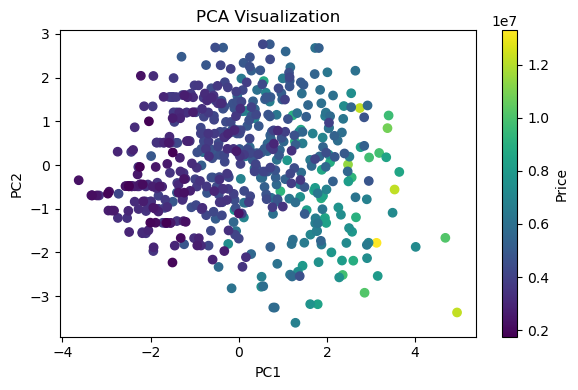

In [15]:
plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['price'], cmap='viridis')
plt.colorbar(label='Price')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Visualization')
plt.tight_layout()

In [16]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_new, y, test_size = 0.2, random_state = 42)

In [17]:
X_train1 = scaler.fit_transform(X_train1)
X_test1 = scaler.transform(X_test1)

In [18]:
model = LinearRegression()
model.fit(X_train1, y_train1)
y_pred_new = model.predict(X_test1)

In [19]:
print("R2:", r2_score(y_test1, y_pred_new))
print("MAE:", mean_absolute_error(y_test1, y_pred_new))
print("RMSE:", np.sqrt(mean_squared_error(y_test1, y_pred_new)))

R2: 0.6529242642153174
MAE: 970043.4039201644
RMSE: 1324506.9600914407


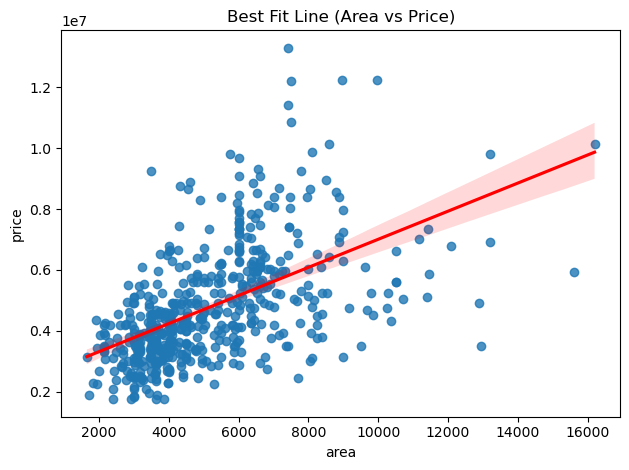

In [20]:
import seaborn as sns
sns.regplot(x='area', y='price', data=df, line_kws={"color": "red"})
plt.title("Best Fit Line (Area vs Price)")
plt.tight_layout()

Through preprocessing, encoding categorical variables, and applying linear regression, the model was able to capture meaningful patterns in housing data, achieving a moderate predictive performance. The results highlight the importance of multiple features and proper data preparation, while also showing the limitations of simple linear models in handling real-world complexity.”